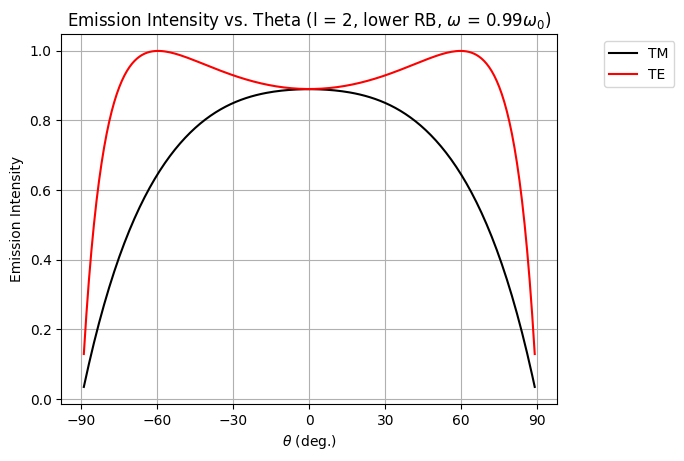

,$\psi_{TM}$ (@ $\omega = 0.99 \omega_{0}$),$\psi_{TE}$ (@ $\omega = 0.99 \omega_{0}$),$h_{e}$ in nm (@ $\omega = 0.99 \omega_{0}$),$h_{m}$ in nm (TM) (@ $\omega = 0.99 \omega_{0}$),$h_{m}$ in nm (TE) (@ $\omega = 0.99 \omega_{0}$),$h_{m}$ in nm (optimal) (@ $\omega = 0.99 \omega_{0}$)
0,3.133012,3.133661,616.526198,12.835004,11.863403,9398.016762


TM at 45°: 0.7785807040427613
TM max: 0.8896776468439763 at angle: 0


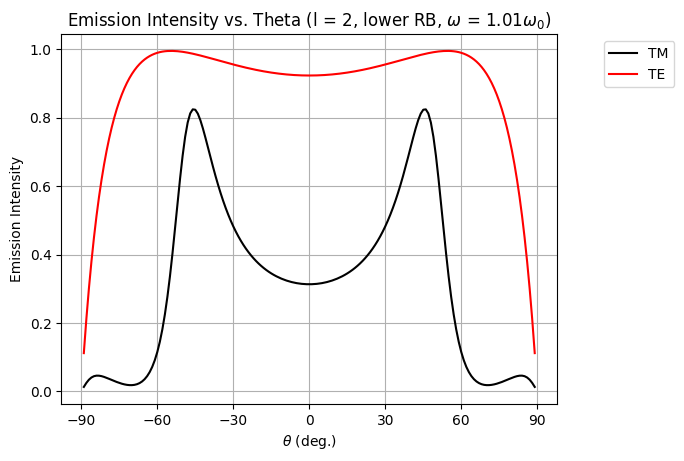

,$\psi_{TM}$ (@ $\omega = 0.99 \omega_{0}$),$\psi_{TE}$ (@ $\omega = 0.99 \omega_{0}$),$h_{e}$ in nm (@ $\omega = 0.99 \omega_{0}$),$h_{m}$ in nm (TM) (@ $\omega = 0.99 \omega_{0}$),$h_{m}$ in nm (TE) (@ $\omega = 0.99 \omega_{0}$),$h_{m}$ in nm (optimal) (@ $\omega = 0.99 \omega_{0}$)
0,4.070593,3.624856,300.144557,-1362.028044,-708.523141,9211.91742


TM at 45°: 0.823263899932577
TM max: 0.8243161679934732 at angle: -46


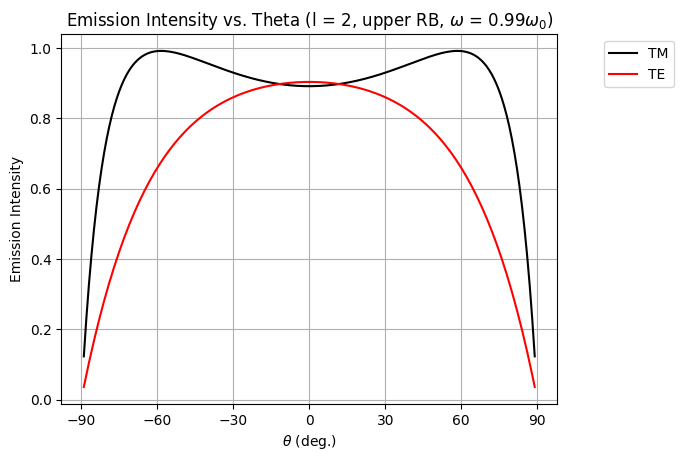

,$\psi_{TM}$ (@ $\omega = 0.99 \omega_{0}$),$\psi_{TE}$ (@ $\omega = 0.99 \omega_{0}$),$h_{e}$ in nm (@ $\omega = 0.99 \omega_{0}$),$h_{m}$ in nm (TM) (@ $\omega = 0.99 \omega_{0}$),$h_{m}$ in nm (TE) (@ $\omega = 0.99 \omega_{0}$),$h_{m}$ in nm (optimal) (@ $\omega = 0.99 \omega_{0}$)
0,3.145397,3.140901,185.010921,-3.179825,0.57792,5251.832897


TM at 45°: 0.9687027357708918
TM max: 0.9912368543231471 at angle: -58


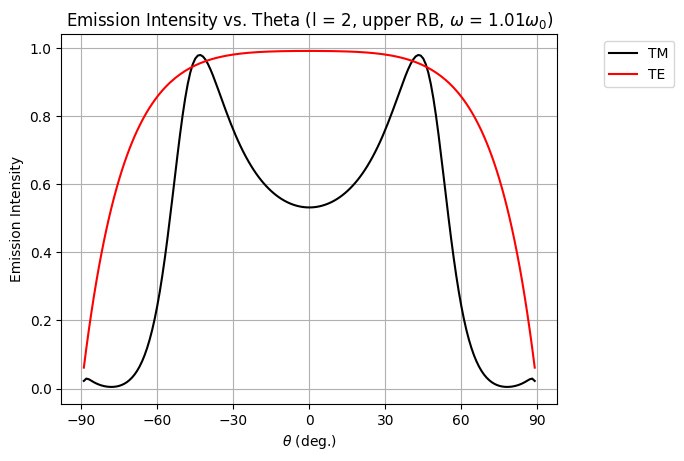

,$\psi_{TM}$ (@ $\omega = 0.99 \omega_{0}$),$\psi_{TE}$ (@ $\omega = 0.99 \omega_{0}$),$h_{e}$ in nm (@ $\omega = 0.99 \omega_{0}$),$h_{m}$ in nm (TM) (@ $\omega = 0.99 \omega_{0}$),$h_{m}$ in nm (TE) (@ $\omega = 0.99 \omega_{0}$),$h_{m}$ in nm (optimal) (@ $\omega = 0.99 \omega_{0}$)
0,3.885255,3.524754,46.997551,-609.285473,-313.925382,5147.836205


TM at 45°: 0.9684247603036755
TM max: 0.9789554787805278 at angle: -43


In [100]:
import numpy as np 
import matplotlib.pyplot as plt 


#Parameters for the Lower Reststrahlen Band --> phonons excited along the a and b axes 

w_TO_low = 760 #transverse optical phonon frequency of lower RB in units of cm^-1 
w_LO_low = 825 #longitudinal optical phonon frequency of lower RB in units of cm^-1 
gamma_low = 2 #damping constant of lower RB in units of cm^-1 
eps_inf_low = 2.95 #high frequency permittivitty (epsilon_infinite) of the lower RB 


#Parameters for the Upper Reststrahlen Band --> phonons excited aong the c-axis 

w_TO_up = 1360 #transverse optical phonon frequency of Upper RB in units of cm^-1 
w_LO_up = 1614 #longitudinal optical phonon frequency of Upper RB in units of cm^-1 
gamma_up = 7 #damping constant of Upper RB in units of cm^-1 
eps_inf_up= 4.90 #high frequency permittivitty (epsilon_infinite) of the Upper RB 

#Defining the frequencies that I want to test. BR --> 'below resonance' and AR --> 'above resonance' 
w_BR_low = 0.99 * w_TO_low 
w_AR_low = 1.01 * w_TO_low

w_BR_up = 0.99 * w_TO_up
w_AR_up = 1.01 * w_TO_up 

#emitter pemittivity 

def eps_emitter(eps_inf, w_LO, w_TO, gamma, w): 
    return eps_inf * ( 1 + (w_LO**2 - w_TO**2) / (w_TO**2 - 1j * gamma * w - w**2) ) #emitter permittivity of the lower reststrahlen band 

eps_emit_BR_low = eps_emitter(eps_inf_low, w_LO_low, w_TO_low, gamma_low, w_BR_low)
eps_emit_AR_low = eps_emitter(eps_inf_low, w_LO_low, w_TO_low, gamma_low, w_AR_low)

eps_emit_BR_up = eps_emitter(eps_inf_up, w_LO_up, w_TO_up, gamma_up, w_BR_up)
eps_emit_AR_up = eps_emitter(eps_inf_up, w_LO_up, w_TO_up, gamma_up, w_AR_up)

#emitter height for AR and BR 
theta_optimal = np.deg2rad(45) #The figures specifically optimized it for 45 degrees, but you can swap it with whatever 

    #check back in this step if things go wrong

lam_TO_BR_low = 1 / w_BR_low  #corresponding wavelength of the w_TO in units of cm 
lam_TO_AR_low = 1 / w_AR_low 

lam_TO_BR_up = 1 / w_BR_up 
lam_TO_AR_up = 1 / w_AR_up 

def emit_height_AR(eps_emitter, lam): #eps emitter contains info about the input frequency 
    first = lam / (8 * np.pi * (np.sqrt(eps_emitter)).imag) 
    second = np.arcsinh( 2 / (np.cos(theta_optimal) * (np.sqrt(eps_emitter)).real) ) 
    return first * second 

def emit_height_BR(eps_emitter, lam): 
    return lam / (4 * (np.sqrt(eps_emitter)).real) 


emit_height_BR_low = emit_height_BR(eps_emit_BR_low, lam_TO_BR_low)
emit_height_AR_low = emit_height_AR(eps_emit_AR_low, lam_TO_AR_low)

emit_height_BR_up = emit_height_BR(eps_emit_BR_up, lam_TO_BR_up)
emit_height_AR_up = emit_height_AR(eps_emit_AR_up, lam_TO_AR_up)

#Psi_TM --> Phase Shift 

eps_spacer = 1 
aleph_m_optimal = np.sqrt( eps_spacer - np.sin(theta_optimal)**2 ) #aleph of the spacer 

def psi_TM(eps_emitter, lam, emitter_height):
    k = 2 * np.pi / lam #wavevector 
    aleph_e = np.sqrt(eps_emitter - np.sin(theta_optimal)**2) #aleph of the spcaer aleph

    T_e = np.tan(emitter_height * k * aleph_e) 

    arg_num = eps_spacer * aleph_e * eps_emitter * np.cos(theta_optimal) + 1j * aleph_e * T_e
    arg_denom = (eps_emitter)**2 * aleph_m_optimal * T_e * np.cos(theta_optimal) - 1j * aleph_e 

    second = 2 * np.arctan( arg_num / arg_denom) 

    final = np.pi - second 

    return final.real #I removed the .real part from the solution here, 05-07-2026 

def psi_TE(eps_emitter, lam, emitter_height):
    k = 2 * np.pi / lam #wavevector 
    aleph_e = np.sqrt(eps_emitter - np.sin(theta_optimal)**2) #aleph of the spcaer 
    T_e = np.tan(emitter_height * k * aleph_e) 

    arg_num = aleph_m_optimal * aleph_e + 1j * np.cos(theta_optimal) * T_e
    arg_denom =  (aleph_e)**2 * T_e + 1j * np.cos(theta_optimal) 

    second = 2 * np.arctan( arg_num / arg_denom) 

    final = np.pi - second 

    return final.real #I removed the .real part from the solution here, 05-07-2026

#remember that these first four would constitute figures 6b and 6c for the lower band, and the last four would be 6b and 6c for upper band 
psi_TM_BR_low = psi_TM(eps_emit_BR_low, lam_TO_BR_low, emit_height_BR_low)
psi_TE_BR_low = psi_TE(eps_emit_BR_low, lam_TO_BR_low, emit_height_BR_low)

psi_TM_AR_low = psi_TM(eps_emit_AR_low, lam_TO_AR_low, emit_height_AR_low)
psi_TE_AR_low = psi_TE(eps_emit_AR_low, lam_TO_AR_low, emit_height_AR_low)



psi_TM_BR_up = psi_TM(eps_emit_BR_up, lam_TO_BR_up, emit_height_BR_up)
psi_TE_BR_up = psi_TE(eps_emit_BR_up, lam_TO_BR_up, emit_height_BR_up)

psi_TM_AR_up = psi_TM(eps_emit_AR_up, lam_TO_AR_up, emit_height_AR_up)
psi_TE_AR_up = psi_TE(eps_emit_AR_up, lam_TO_AR_up, emit_height_AR_up)

#calculating spacer height 
l = 1 #I set the interference order to be 2, because setting it = 1 would make the spacer layer too close to 0, which wouldn't sastisfy phase condition 

def spacer_height(psi, lam):
    k = 2 * np.pi / lam #wavevector

    num = 2 * l * np.pi - np.pi - psi 
    denom = 2 * k * aleph_m_optimal 

    answer = num / denom 

    return answer  

#hs = height spacer or 'spacer height' 

hs_TM_BR_low = spacer_height(psi_TM_BR_low, lam_TO_BR_low)
hs_TE_BR_low = spacer_height(psi_TE_BR_low, lam_TO_BR_low)

hs_TM_AR_low = spacer_height(psi_TM_AR_low, lam_TO_AR_low) 
hs_TE_AR_low = spacer_height(psi_TE_AR_low, lam_TO_AR_low) 


hs_TM_BR_up = spacer_height(psi_TM_BR_up, lam_TO_BR_up) 
hs_TE_BR_up = spacer_height(psi_TE_BR_up, lam_TO_BR_up)

hs_TM_AR_up = spacer_height(psi_TM_AR_up, lam_TO_AR_up)  
hs_TE_AR_up = spacer_height(psi_TE_AR_up, lam_TO_AR_up) 


def reflection_TM(theta, eps_emitter, emitter_height, spacer_height, lam):
    k = 2 * np.pi / lam #wavevector 
    aleph_e = np.sqrt(eps_emitter - np.sin(theta)**2) #aleph of the emitter
    aleph_m = np.sqrt( eps_spacer - np.sin(theta)**2 ) #aleph of the spacer 

    T_e = np.tan(emitter_height * k * aleph_e) 
    T_m = np.tan(spacer_height * k * aleph_m)

    num = np.cos(theta) * ( 1 - (eps_emitter * aleph_m * T_e * T_m)/(eps_spacer * aleph_e) ) + 1j * ( (aleph_e * T_e)/(eps_emitter) + (aleph_m * T_m)/(eps_spacer) ) 
    denom = np.cos(theta) * ( 1 - (eps_emitter * aleph_m * T_e * T_m)/(eps_spacer * aleph_e) ) - 1j * ( (aleph_e * T_e)/(eps_emitter) + (aleph_m * T_m)/(eps_spacer) ) 

    r_TM = num / denom 

    R_TM = ( r_TM * r_TM.conjugate() ).real

    return R_TM 


def reflection_TE(theta, eps_emitter, emitter_height, spacer_height, lam):
    k = 2 * np.pi / lam #wavevector 
    aleph_e = np.sqrt(eps_emitter - np.sin(theta)**2) #aleph of the spcaer aleph
    aleph_m = np.sqrt(eps_spacer - np.sin(theta)**2 ) #aleph of the spacer 

    T_e = np.tan(emitter_height * k * aleph_e) 
    T_m = np.tan(spacer_height * k * aleph_m)

    num = ( 1 - (aleph_e * T_e * T_m)/(aleph_m) ) + 1j * np.cos(theta) * ( (T_e)/(aleph_e) + (T_m)/(aleph_m) ) 
    denom = ( 1 - (aleph_e * T_e * T_m)/(aleph_m) ) - 1j * np.cos(theta) * ( (T_e)/(aleph_e) + (T_m)/(aleph_m) )

    r_TE = num / denom 

    R_TE = ( r_TE * r_TE.conjugate() ).real 

    return R_TE  

angles = np.deg2rad(np.arange(-89, 90, 1)) #probing from -90 degrees to 90 degrees) 

angles_plotting = np.arange(-89, 90, 1)


#plotting 

Emission_TM_BR_low = 1 - reflection_TM(angles, eps_emit_BR_low, emit_height_BR_low, hs_TM_BR_low, lam_TO_BR_low)
Emission_TE_BR_low = 1 - reflection_TE(angles, eps_emit_BR_low, emit_height_BR_low, hs_TE_BR_low, lam_TO_BR_low)

plt.plot(angles_plotting, Emission_TM_BR_low, color = 'black', label = 'TM')
plt.plot(angles_plotting, Emission_TE_BR_low, color = 'red', label = 'TE')
plt.title(r'Emission Intensity vs. Theta (l = 2, lower RB, $\omega$ = $0.99\omega_{0})$') 
#plt.axvline(x = 45, linestyle = '--', color = 'blue') 
#plt.axvline(x = -45, linestyle = '--', color = 'blue')
plt.xlabel(r'$\theta$ (deg.)')
plt.ylabel('Emission Intensity')
plt.xticks([-90, -60, -30, 0, 30, 60, 90])
plt.grid(True)
plt.legend(bbox_to_anchor = (1.08, 1), loc = 'upper left') 
plt.show()

import pandas as pd

df_BR_low = pd.DataFrame({
    r'$\psi_{TM}$ (@ $\omega = 0.99 \omega_{0}$)': [psi_TM_BR_low],
    r'$\psi_{TE}$ (@ $\omega = 0.99 \omega_{0}$)': [psi_TE_BR_low],
    r'$h_{e}$ in nm (@ $\omega = 0.99 \omega_{0}$)': [emit_height_BR_low * 1E7],
    r'$h_{m}$ in nm (TM) (@ $\omega = 0.99 \omega_{0}$)': [hs_TM_BR_low * 1E7],
    r'$h_{m}$ in nm (TE) (@ $\omega = 0.99 \omega_{0}$)': [hs_TE_BR_low * 1E7],
    r'$h_{m}$ in nm (optimal) (@ $\omega = 0.99 \omega_{0}$)': [lam_TO_BR_low / (2 * aleph_m_optimal)  * 1E7]
})

display(df_BR_low)

idx_45 = np.where(angles_plotting == 45)[0][0]
print("TM at 45°:", Emission_TM_BR_low[idx_45])
print("TM max:", np.max(Emission_TM_BR_low), "at angle:", angles_plotting[np.argmax(Emission_TM_BR_low)])



Emission_TM_AR_low = 1 - reflection_TM(angles, eps_emit_AR_low, emit_height_AR_low, hs_TM_AR_low, lam_TO_AR_low)
Emission_TE_AR_low = 1 - reflection_TE(angles, eps_emit_AR_low, emit_height_AR_low, hs_TE_AR_low, lam_TO_AR_low)

plt.plot(angles_plotting, Emission_TM_AR_low, color = 'black', label = 'TM')
plt.plot(angles_plotting, Emission_TE_AR_low, color = 'red', label = 'TE')
plt.title(r'Emission Intensity vs. Theta (l = 2, lower RB, $\omega$ = $1.01\omega_{0})$') 
#plt.axvline(x = 45, linestyle = '--', color = 'blue') 
#plt.axvline(x = -45, linestyle = '--', color = 'blue')
plt.xlabel(r'$\theta$ (deg.)')
plt.ylabel('Emission Intensity')
plt.xticks([-90, -60, -30, 0, 30, 60, 90])
plt.grid(True)
plt.legend(bbox_to_anchor = (1.08, 1), loc = 'upper left') 
plt.show()

import pandas as pd

df_AR_low = pd.DataFrame({
    r'$\psi_{TM}$ (@ $\omega = 0.99 \omega_{0}$)': [psi_TM_AR_low],
    r'$\psi_{TE}$ (@ $\omega = 0.99 \omega_{0}$)': [psi_TE_AR_low],
    r'$h_{e}$ in nm (@ $\omega = 0.99 \omega_{0}$)': [emit_height_AR_low * 1E7],
    r'$h_{m}$ in nm (TM) (@ $\omega = 0.99 \omega_{0}$)': [hs_TM_AR_low * 1E7],
    r'$h_{m}$ in nm (TE) (@ $\omega = 0.99 \omega_{0}$)': [hs_TE_AR_low * 1E7],
    r'$h_{m}$ in nm (optimal) (@ $\omega = 0.99 \omega_{0}$)': [lam_TO_AR_low / (2 * aleph_m_optimal)  * 1E7]
})

display(df_AR_low)

idx_45 = np.where(angles_plotting == 45)[0][0]
print("TM at 45°:", Emission_TM_AR_low[idx_45])
print("TM max:", np.max(Emission_TM_AR_low), "at angle:", angles_plotting[np.argmax(Emission_TM_AR_low)])


#upper band 
Emission_TM_BR_up = 1 - reflection_TM(angles, eps_emit_BR_up, emit_height_BR_up, hs_TM_BR_up, lam_TO_BR_up)
Emission_TE_BR_up = 1 - reflection_TE(angles, eps_emit_BR_up, emit_height_BR_up, hs_TE_BR_up, lam_TO_BR_up)

plt.plot(angles_plotting, Emission_TM_BR_up, color = 'black', label = 'TM')
plt.plot(angles_plotting, Emission_TE_BR_up, color = 'red', label = 'TE')
plt.title(r'Emission Intensity vs. Theta (l = 2, upper RB, $\omega$ = $0.99\omega_{0})$') 
#plt.axvline(x = 45, linestyle = '--', color = 'blue') 
#plt.axvline(x = -45, linestyle = '--', color = 'blue')
plt.xlabel(r'$\theta$ (deg.)')
plt.ylabel('Emission Intensity')
plt.xticks([-90, -60, -30, 0, 30, 60, 90])
plt.grid(True)
plt.legend(bbox_to_anchor = (1.08, 1), loc = 'upper left') 
plt.show()


df_BR_up = pd.DataFrame({
    r'$\psi_{TM}$ (@ $\omega = 0.99 \omega_{0}$)': [psi_TM_BR_up],
    r'$\psi_{TE}$ (@ $\omega = 0.99 \omega_{0}$)': [psi_TE_BR_up],
    r'$h_{e}$ in nm (@ $\omega = 0.99 \omega_{0}$)': [emit_height_BR_up * 1E7],
    r'$h_{m}$ in nm (TM) (@ $\omega = 0.99 \omega_{0}$)': [hs_TM_BR_up * 1E7],
    r'$h_{m}$ in nm (TE) (@ $\omega = 0.99 \omega_{0}$)': [hs_TE_BR_up * 1E7],
    r'$h_{m}$ in nm (optimal) (@ $\omega = 0.99 \omega_{0}$)': [lam_TO_BR_up / (2 * aleph_m_optimal)  * 1E7]
})

display(df_BR_up)

idx_45 = np.where(angles_plotting == 45)[0][0]
print("TM at 45°:", Emission_TM_BR_up[idx_45])
print("TM max:", np.max(Emission_TM_BR_up), "at angle:", angles_plotting[np.argmax(Emission_TM_BR_up)])



Emission_TM_AR_up = 1 - reflection_TM(angles, eps_emit_AR_up, emit_height_AR_up, hs_TM_AR_up, lam_TO_AR_up)
Emission_TE_AR_up = 1 - reflection_TE(angles, eps_emit_AR_up, emit_height_AR_up, hs_TE_AR_up, lam_TO_AR_up)

plt.plot(angles_plotting, Emission_TM_AR_up, color = 'black', label = 'TM')
plt.plot(angles_plotting, Emission_TE_AR_up, color = 'red', label = 'TE')
plt.title(r'Emission Intensity vs. Theta (l = 2, upper RB, $\omega$ = $1.01\omega_{0})$') 
#plt.axvline(x = 45, linestyle = '--', color = 'blue') 
#plt.axvline(x = -45, linestyle = '--', color = 'blue')
plt.xlabel(r'$\theta$ (deg.)')
plt.ylabel('Emission Intensity')
plt.xticks([-90, -60, -30, 0, 30, 60, 90])
plt.grid(True)
plt.legend(bbox_to_anchor = (1.08, 1), loc = 'upper left') 
plt.show()

df_AR_up = pd.DataFrame({
    r'$\psi_{TM}$ (@ $\omega = 0.99 \omega_{0}$)': [psi_TM_AR_up],
    r'$\psi_{TE}$ (@ $\omega = 0.99 \omega_{0}$)': [psi_TE_AR_up],
    r'$h_{e}$ in nm (@ $\omega = 0.99 \omega_{0}$)': [emit_height_AR_up * 1E7],
    r'$h_{m}$ in nm (TM) (@ $\omega = 0.99 \omega_{0}$)': [hs_TM_AR_up * 1E7],
    r'$h_{m}$ in nm (TE) (@ $\omega = 0.99 \omega_{0}$)': [hs_TE_AR_up * 1E7],
    r'$h_{m}$ in nm (optimal) (@ $\omega = 0.99 \omega_{0}$)': [lam_TO_AR_up / (2 * aleph_m_optimal)  * 1E7]
})

display(df_AR_up)

idx_45 = np.where(angles_plotting == 45)[0][0]
print("TM at 45°:", Emission_TM_AR_up[idx_45])
print("TM max:", np.max(Emission_TM_AR_up), "at angle:", angles_plotting[np.argmax(Emission_TM_AR_up)])

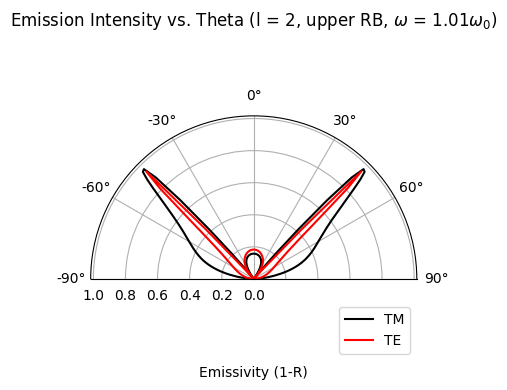

In [99]:
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(6, 4))

# Convert angles to radians, but shift so 0° is at top and 90° is to the sides
# In matplotlib polar, 0 is to the right and goes counterclockwise
# We need to remap: paper's theta=0 -> pi/2 in mpl, paper's theta=90 -> 0 in mpl

angles_rad = np.deg2rad(angles_plotting)

# Remap to polar coordinates matching the paper
polar_angles = angles_rad  # shift so 0° is at top



#Plotting each one
ax.plot(polar_angles, Emission_TM_AR_up, color='black', label='TM')
ax.plot(polar_angles, Emission_TE_AR_up, color='red', label='TE')

# Restrict to upper half (0 to 180 degrees)
ax.set_thetamin(-90)
ax.set_thetamax(90)

ax.set_theta_zero_location('N')  # 0° at top
ax.set_theta_direction(-1)        # clockwise

ax.set_rlabel_position(90)
ax.set_xlabel('Emissivity (1-R)')
ax.legend(loc='lower right')
ax.set_title(r'Emission Intensity vs. Theta (l = 2, upper RB, $\omega$ = $1.01\omega_{0})$')
plt.tight_layout()
plt.show()